In [16]:
import pandas as pd
from glob import glob
import os
import sys
from joblib import Parallel, delayed
from tqdm import tqdm
import subprocess
import zipfile
import requests
import py3Dmol
from pymol import cmd
from rdkit import Chem

### Unzip data

In [5]:
for zip_file in glob("source_data/*"):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("extracted_data")

### Extract data

In [6]:
df_list = []
for csv_path in glob("extracted_data/*.csv"):
    df_ = pd.read_csv(csv_path, index_col=False)
    df_[df_.columns[2]] = df_.columns[2]
    df_.columns = [str(i) for i in range(10)]
    df_list.append(df_)
    
df = pd.concat(df_list)
df = df.drop(columns=["0", "1"])

In [7]:
df_kd = df[(df["4"] != "Part of Protein") & (~df["5"].isna())]
df_kd = df_kd[(df_kd["5"] == "Kd") & (df_kd["4"] == "valid") & (~df_kd["2"].duplicated(keep=False))]
df_kd = df_kd[~df_kd["3"].apply(lambda x: " " in x.split(":")[0])]
df_kd = df_kd.reset_index(drop=True)
df_kd

,2,3,4,5,6,7,8,9
0,5EPR,5QY:A:801,valid,Kd,=,9.100000e+01,uM,C[C@H]1C(=O)Nc2ccccc2N1
1,2O4K,DR7:A:301,valid,Kd,=,3.500000e+01,pM,CC(C)(C)[C@@H](C(=O)N[C@@H](Cc1ccccc1)[C@H](CN...
2,6ELO,BAW:A:301,valid,Kd,=,6.400000e-08,M,CCc1cc(c(cc1O)O)c2c(c(n[nH]2)C)c3ccccc3F
3,5UXN,TYR:A:505,valid,Kd,=,2.300000e+01,uM,c1cc(ccc1C[C@@H](C(=O)O)N)O
4,3ZHZ,FM7:A:1390,valid,Kd,=,9.000000e-02,uM,c1ccc(c(c1)C(=O)N(CC[C@@H](c2ccc(c(c2)Cl)Cl)P(...
...,...,...,...,...,...,...,...,...
2223,5CPR,539:B:403,valid,Kd,=,2.780000e+01,nM,c1cnccc1c2c3cc(c(cc3c(nn2)NC4CCCC4)Cl)Cl
2224,6TDF,N3Q:A:202,valid,Kd,=,5.000000e+00,uM,c1c(cc(c(c1Cl)c2[nH]cnn2)Cl)N(CCO)CCO
2225,5L1V,7PF:A:401,valid,Kd,=,4.300000e+01,uM,CC1(C[C@H]2C=C([C@H]3[C@]2(C1)[C@@]4(CO4)C(=O)...
2226,5VB5,92A:A:602,valid,Kd,=,3.500000e-01,uM,CC1CCN(CC1)C(=O)[C@@H](Cc2ccc(cc2)NC(=O)CCc3cc...


In [8]:
df_kd.to_csv("selected_data.csv", index=False)

### Clean data

In [9]:
import math
units_dict = { "M" : 0, "mM" : -3, "uM" : -6, "nM" : -9, "pM" : -12, "fM" : -15 } 

In [10]:
df_kd = pd.read_csv("selected_data.csv")
df_kd = df_kd[df_kd["6"] == "="]
df_kd = df_kd.rename(columns={"2" : "PDB ID", "3" : "PDB ligand position", "9" : "SMILES"})
df_kd["pKd"] = df_kd[["7", "8"]].apply(lambda x: - (units_dict[x[1]] + math.log(x[0], 10)), axis=1)
df_kd = df_kd.drop(columns=["4", "5", "6", "7", "8"])
df_kd

,PDB ID,PDB ligand position,SMILES,pKd
0,5EPR,5QY:A:801,C[C@H]1C(=O)Nc2ccccc2N1,4.040959
1,2O4K,DR7:A:301,CC(C)(C)[C@@H](C(=O)N[C@@H](Cc1ccccc1)[C@H](CN...,10.455932
2,6ELO,BAW:A:301,CCc1cc(c(cc1O)O)c2c(c(n[nH]2)C)c3ccccc3F,7.193820
3,5UXN,TYR:A:505,c1cc(ccc1C[C@@H](C(=O)O)N)O,4.638272
4,3ZHZ,FM7:A:1390,c1ccc(c(c1)C(=O)N(CC[C@@H](c2ccc(c(c2)Cl)Cl)P(...,7.045757
...,...,...,...,...
2222,3GCV,SS6:A:361,Cc1cccc(c1)n2c(cc(n2)C(C)(C)C)NC(=O)Nc3cccc(c3...,7.130768
2223,5CPR,539:B:403,c1cnccc1c2c3cc(c(cc3c(nn2)NC4CCCC4)Cl)Cl,7.555955
2224,6TDF,N3Q:A:202,c1c(cc(c(c1Cl)c2[nH]cnn2)Cl)N(CCO)CCO,5.301030
2225,5L1V,7PF:A:401,CC1(C[C@H]2C=C([C@H]3[C@]2(C1)[C@@]4(CO4)C(=O)...,4.366532


In [11]:
df_kd.to_csv("cleaned_data.csv", index=False)

### Prepare complexes

In [2]:
df_kd = pd.read_csv("cleaned_data.csv")
df_kd.head(3)

,PDB ID,PDB ligand position,SMILES,pKd
0,5EPR,5QY:A:801,C[C@H]1C(=O)Nc2ccccc2N1,4.040959
1,2O4K,DR7:A:301,CC(C)(C)[C@@H](C(=O)N[C@@H](Cc1ccccc1)[C@H](CN...,10.455932
2,6ELO,BAW:A:301,CCc1cc(c(cc1O)O)c2c(c(n[nH]2)C)c3ccccc3F,7.193820


In [3]:
df_kd.shape

(2166, 4)

#### Fetch complexes

In [ ]:
os.makedirs("complexes", exist_ok=True)

for pdb_id in df_kd["PDB ID"]:
    os.makedirs(f"complexes/{pdb_id}", exist_ok=True)
    cmd.fetch(pdb_id, '', 0, 1, -1, -2, -1, "pdb", 1, file=f"complexes/{pdb_id}/complex.pdb")

### Prepare complex for reduce

In [38]:
# for file_path in glob("complexes/*/*"):
#     if os.path.basename(file_path) != "complex.pdb":
#         os.remove(file_path)

In [29]:
for pdb_id, ligand_position in df_kd[["PDB ID", "PDB ligand position"]].values:
    lig_name, lig_chain, lig_index = ligand_position.split(":")
    cmd.load(f"complexes/{pdb_id}/complex.pdb")
    #cmd.save(f"complexes/{pdb_id}/ligand.pdb", f'c. {lig_chain} and i. {lig_index} and alt A+""')
    cmd.remove(f'c. {lig_chain} and i. {lig_index}')
    cmd.remove('elem H')
    cmd.save(f"complexes/{pdb_id}/complex_altA.pdb", 'altconf, alt A+""')
    cmd.reinitialize()

In [28]:
count = 0 

for pdb_id in df_kd["PDB ID"]:
    cmd.load(f"complexes/{pdb_id}/complex.pdb")
    if cmd.count_atoms('altconf, alt B') > 0:
        #print(pdb_id)
        count += 1
    cmd.reinitialize()
print(count)

1362


### Download ligands sdf

In [73]:
def get_lig_sdf(pdb_id, ligand_position):
    lig_name, lig_chain, lig_index = ligand_position.split(":")
    req_result = requests.get(f"https://models.rcsb.org/v1/{pdb_id}/ligand?auth_seq_id={lig_index}&auth_asym_id={lig_chain}&encoding=sdf")
    if req_result.status_code == 200:
        with open(f"complexes/{pdb_id}/ligand.sdf", "w") as file_sdf:
            file_sdf.write(req_result.content.decode("utf-8"))

In [74]:
exit_codes = Parallel(n_jobs=12, verbose=0)(delayed(get_lig_sdf)(pdb_id, ligand_position) for pdb_id, ligand_position in tqdm(df_kd[["PDB ID", "PDB ligand position"]].values))

100%|██████████| 2166/2166 [04:27<00:00,  8.10it/s]


### Check complexes and ligs

In [75]:
print(len([file_path for file_path in glob("complexes/*/ligand.sdf")]))
print(len([file_path for file_path in glob("complexes/*/complex_altA.pdb")]))

2165
2166


In [37]:
close_contacts = []

for pdb_id, ligand_position in df_kd[["PDB ID", "PDB ligand position"]].values:
    if not os.path.exists(f"complexes/{pdb_id}/complex_altA.pdb") or not os.path.exists(f"complexes/{pdb_id}/ligand.sdf"):
        continue
    cmd.load(f"complexes/{pdb_id}/complex_altA.pdb")
    cmd.load(f"complexes/{pdb_id}/ligand.sdf")
    cmd.remove('elem H')
    if cmd.count_atoms("(ligand) around 1.5") > 0:
        print(pdb_id, ligand_position)
        close_contacts.append(pdb_id)
    else:
        cmd.save(f"complexes/{pdb_id}/complex_altA_ligand.pdb")
    cmd.reinitialize()

4GS9 0XB:A:401
4JFL 1KY:A:201
3RDM BTN:A:300
6CH5 F0M:A:208
4JFK JFK:A:201
3M4H 388:A:600
1VYR TNF:A:1402
2VMC A2G:A:501
6IPL DTP:A:502
2VBA P4T:A:1405
2WDY COA:A:1128
2PYN 1UN:A:1001
2PYM 1UN:A:1001
4R5E AO3:A:403
6IPN DGT:A:502
2Q63 1UN:A:1001


### Add hydrogens to complex using reduce

In [9]:
def run_reduce(pdb_id):
    cmd_args = ["/share/amber22/bin/reduce", "-build", "-nuclear", f"complexes/{pdb_id}/complex_altA_ligand.pdb"]
    
    try:
        result = subprocess.run(cmd_args, capture_output=True, timeout=30)
    except subprocess.TimeoutExpired:
        return f"TimeoutExpired: {pdb_id}"
    
    with open(f"complexes/{pdb_id}/complex_altA_ligand_h.pdb", "w") as file_out:
        file_out.write(result.stdout.decode("utf-8").strip())

In [14]:
exit_codes = Parallel(n_jobs=12, verbose=0)(delayed(run_reduce)(pdb_id) for pdb_id in tqdm(df_kd["PDB ID"]))

100%|██████████| 2166/2166 [07:20<00:00,  4.92it/s]


In [15]:
timeout_codes = [code for code in exit_codes if code is not None]
print(len(timeout_codes))

0


In [22]:
for pdb_id in df_kd["PDB ID"]:
    if not os.path.exists(f"complexes/{pdb_id}/complex_altA_ligand_h.pdb") or not os.path.exists(f"complexes/{pdb_id}/ligand.sdf"):
        continue
    cmd.load(f"complexes/{pdb_id}/complex_altA_ligand_h.pdb")
    cmd.remove("sol or ino or org")
    cmd.save(f"complexes/{pdb_id}/protein.pdb")
    cmd.reinitialize()
    mol = Chem.MolFromMolFile(f"complexes/{pdb_id}/ligand.sdf")
    if mol is None:
        continue
    mol = Chem.AddHs(mol, addCoords=True)
    Chem.MolToPDBFile(mol, f"complexes/{pdb_id}/ligand.pdb", flavor=20)

[17:54:14] Explicit valence for atom # 13 N, 4, is greater than permitted
[17:54:29] Explicit valence for atom # 5 N, 4, is greater than permitted
[17:54:35] Explicit valence for atom # 0 Cl, 2, is greater than permitted
[17:54:38] Explicit valence for atom # 2 O, 3, is greater than permitted
[17:54:43] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:54:43] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:54:53] Explicit valence for atom # 13 N, 4, is greater than permitted
[17:55:00] Explicit valence for atom # 2 O, 3, is greater than permitted
[17:55:02] Explicit valence for atom # 0 N, 4, is greater than permitted
[17:55:06] Explicit valence for atom # 10 O, 3, is greater than permitted


for file_path in glob("complexes/*/*"):
    if os.path.basename(file_path) == "restored_ligand_out.pdbqt":
        os.remove(file_path)

## Prepare ligands PDBQT

In [28]:
def pdb_to_pdbqt(pdb_file, pdbqt_file, mgl_python, overwrite=True, silent=False):  
    if not os.path.exists(mgl_python):
        raise Exception("MGL python is not exists")
        
    if not overwrite and os.path.exists(pdbqt_file):
         return
    
    pdb_name = os.path.dirname(pdb_file).split(os.sep)[-1]
    
    cmd_args = [mgl_python, "prepare_ligand4.py", '-l', pdb_file, '-o', pdbqt_file]#, '-A', 'hydrogens']

    try:
        result = subprocess.run(cmd_args, capture_output=True, timeout=30)
    except subprocess.TimeoutExpired:
        if not silent:
            print('\nTimeoutExpired:', pdb_name)
        return pdb_name

    if result.returncode:
        if not silent:
            print('\nError:', pdb_name, "-", result.stderr.decode("utf-8").strip())
        return pdb_name

    return 1

def pdb_dir_to_pdbqt(complexes_dir, mgl_python, cpu_count=2, overwrite=True, silent=False):
    if not os.path.exists(complexes_dir):
        raise Exception("Complexes directory is not exists")

    if not os.path.exists(mgl_python):
        raise Exception("MGL python is not exists")

    cpu_count = min(os.cpu_count(), cpu_count)
    exit_codes = Parallel(n_jobs=cpu_count, verbose=0)(delayed(pdb_to_pdbqt)(pdb_file, os.path.dirname(pdb_file) + "/ligand.pdbqt", mgl_python, overwrite, silent) for pdb_file in tqdm(glob(f"{complexes_dir}/*/ligand.pdb")))

    pdb_num = len(exit_codes)
    bad_pdb_list = []
    converted_pdb_num = 0

    for code in exit_codes:
        if code == 1:
            converted_pdb_num += 1
        elif type(code) is str:
            bad_pdb_list.append(code)

    return pdb_num, converted_pdb_num, bad_pdb_list

In [29]:
pdb_dir_to_pdbqt("complexes", "/share/mgltools_x86_64Linux2_1.5.6/bin/pythonsh", cpu_count=12)

100%|██████████| 2155/2155 [00:23<00:00, 91.51it/s] 


(2155, 2152, ['3BHO', '1LR8', '3HLO'])

## Prepare proteins PDBQT

In [30]:
def rec_pdb_to_pdbqt(pdb_file, pdbqt_file, mgl_python, overwrite=True, silent=False):  
    if not os.path.exists(mgl_python):
        raise Exception("MGL python is not exists")
        
    if not overwrite and os.path.exists(pdbqt_file):
         return
    
    pdb_name = os.path.dirname(pdb_file).split(os.sep)[-1]
    
    cmd_args = [mgl_python, "prepare_receptor4.py", '-r', pdb_file, '-o', pdbqt_file]#, '-A', 'checkhydrogens']

    try:
        result = subprocess.run(cmd_args, capture_output=True, timeout=30)
    except subprocess.TimeoutExpired:
        if not silent:
            print('\nTimeoutExpired:', pdb_name)
        return pdb_name

    if result.returncode:
        if not silent:
            print('\nError:', pdb_name, "-", result.stderr.decode("utf-8").strip())
        return pdb_name

    return 1

def rec_pdb_dir_to_pdbqt(complexes_dir, mgl_python, cpu_count=2, overwrite=True, silent=False):
    if not os.path.exists(complexes_dir):
        raise Exception("Complexes directory is not exists")

    if not os.path.exists(mgl_python):
        raise Exception("MGL python is not exists")

    cpu_count = min(os.cpu_count(), cpu_count)
    exit_codes = Parallel(n_jobs=cpu_count, verbose=0)(delayed(rec_pdb_to_pdbqt)(pdb_file, os.path.dirname(pdb_file) + "/protein.pdbqt", mgl_python, overwrite, silent) for pdb_file in tqdm(glob(f"{complexes_dir}/*/protein.pdb")))

    pdb_num = len(exit_codes)
    bad_pdb_list = []
    converted_pdb_num = 0

    for code in exit_codes:
        if code == 1:
            converted_pdb_num += 1
        elif type(code) is str:
            bad_pdb_list.append(code)

    return pdb_num, converted_pdb_num, bad_pdb_list

In [ ]:
pdb_num, converted_pdb_num, bad_pdb_list = rec_pdb_dir_to_pdbqt("complexes", "/share/mgltools_x86_64Linux2_1.5.6/bin/pythonsh", cpu_count=12)

 22%|██▏       | 480/2165 [00:51<03:11,  8.81it/s]

In [33]:
pdb_num, converted_pdb_num

(2165, 2148)

# Scoring

## Check if all file converted to pdbqt

In [35]:
df_score = pd.read_csv("cleaned_data.csv")
print(df_score.shape)
df_score.head(3)

(2166, 4)


,PDB ID,PDB ligand position,SMILES,pKd
0,5EPR,5QY:A:801,C[C@H]1C(=O)Nc2ccccc2N1,4.040959
1,2O4K,DR7:A:301,CC(C)(C)[C@@H](C(=O)N[C@@H](Cc1ccccc1)[C@H](CN...,10.455932
2,6ELO,BAW:A:301,CCc1cc(c(cc1O)O)c2c(c(n[nH]2)C)c3ccccc3F,7.193820


In [36]:
df_score["Protein converted"] = df_score["PDB ID"].apply(lambda x: os.path.exists(f"complexes/{x}/protein.pdbqt"))
df_score["Ligand converted"] = df_score["PDB ID"].apply(lambda x: os.path.exists(f"complexes/{x}/ligand.pdbqt"))
df_score = df_score[(df_score["Protein converted"]) & (df_score["Ligand converted"])]
df_score = df_score.drop(columns=["Protein converted", "Ligand converted"])
print(df_score.shape)

(2138, 4)


In [43]:
import math

#J/(K*mol) / kcal/J -> kcal/(K*mol)
kcal_to_jole = 4184
# Universal gas constant
R = 8.31432
# Temperature, K
T = 298.5

def get_vina_pKd(pdb_id):
    receptor_file = f"complexes/{pdb_id}/protein.pdbqt"
    ligand_file = f"complexes/{pdb_id}/ligand.pdbqt"

    cmd_args = ["/share/chemplus/src/chemplus/vina/sf/autodock_vina/vina", "--receptor", receptor_file, 
                "--ligand", ligand_file, "--score_only", "--autobox"]

    result = subprocess.run(cmd_args, capture_output=True, shell=False)

    if result.returncode:
        return result.stderr.decode("utf-8").strip()
    else:
        #pdbqt_content = open(f"complexes/{pdb_id}/restored_ligand_out.pdbqt").readlines()[:-1]
        #open(f"complexes/{pdb_id}/restored_ligand_out.pdbqt", 'w').writelines(pdbqt_content)
        score_out = result.stdout.decode("utf-8").strip()
        score_begin_index = score_out.find("Estimated Free Energy of Binding   :") + 36
        score_end_index = score_begin_index + score_out[score_begin_index:].find("(")
        energy = float(score_out[score_begin_index:score_end_index].strip())
        return - energy * kcal_to_jole / R / T / math.log(10)

def get_nn2_pKd(pdb_id):
    nn2_script = "/share/chemplus/src/chemplus/vina/sf/nnscore2.0/NNScore2.py"
    receptor_file = f"complexes/{pdb_id}/protein.pdbqt"
    ligand_file = f"complexes/{pdb_id}/ligand.pdbqt"
    cmd_args = [sys.executable, nn2_script, "-receptor", receptor_file, "-ligand", ligand_file]
    result = subprocess.run(cmd_args, capture_output=True, shell=False)
    
    if result.returncode:
        return result.stderr.decode("utf-8").strip()
    else:
        score_out = result.stdout.decode("utf-8").strip()
        lines = score_out.split("\n")
        for idx, line in enumerate(lines):
            if "AVERAGE SCORE OF ALL 20 NETWORKS, BY POSE" in line:
                score_line = lines[idx+3]
                splitted_line = score_line.split('|')
                pKd = float(splitted_line[2])
                return pKd
        raise Exception("Not found NN2 score")

def get_rf4_pKd(pdb_id):
    rf4 = "/share/chemplus/src/chemplus/vina/sf/rfscore4/rf-score"
    rf4_model = "/share/chemplus/src/chemplus/vina/sf/rfscore4/pdbbind-2014-refined.rf"
    receptor_file = f"complexes/{pdb_id}/protein.pdbqt"
    ligand_file = f"complexes/{pdb_id}/ligand.pdbqt"
    cmd_args = [rf4, rf4_model, receptor_file, ligand_file]
    result = subprocess.run(cmd_args, capture_output=True, shell=False)
    
    if result.returncode:
        return result.stderr.decode("utf-8").strip()
    else:
        score_out = result.stdout.decode("utf-8").strip()
        try:
            return float(score_out)
        except:
            return score_out

In [ ]:
df_score["VINA pKd"] = Parallel(n_jobs=14, verbose=0)(delayed(get_vina_pKd)(pdb_id) for pdb_id in tqdm(df_score["PDB ID"]))
df_score["NN2 pKd"] = Parallel(n_jobs=14, verbose=0)(delayed(get_nn2_pKd)(pdb_id) for pdb_id in tqdm(df_score["PDB ID"]))
df_score["RF4 pKd"] = Parallel(n_jobs=14, verbose=0)(delayed(get_rf4_pKd)(pdb_id) for pdb_id in tqdm(df_score["PDB ID"]))

In [45]:
not_computed_pKd = ((df_score["VINA pKd"].apply(lambda x: type(x) is not float)) | 
                    (df_score["NN2 pKd"].apply(lambda x: type(x) is not float)) | 
                    (df_score["RF4 pKd"].apply(lambda x: type(x) is not float)))

print(df_score[not_computed_pKd].shape[0])
df_score[not_computed_pKd]

11


,PDB ID,PDB ligand position,SMILES,pKd,VINA pKd,NN2 pKd,RF4 pKd
343,6KVQ,DVX:A:403,[B-]1(n2c(ccc2CCC(=O)OC[C@H](c3nc(c(o3)Br)c4cc...,6.055517,PDBQT parsing error: Atom type B is not a vali...,"Parse error on line 44 in file ""complexes/6KVQ...",8.35
654,2ILZ,GTP:A:1001,c1nc2c(n1[C@H]3[C@@H]([C@@H]([C@H](O3)CO[P@](=...,5.397940,PDBQT parsing error: Atom type As is not a val...,"Parse error on line 934 in file ""complexes/2IL...",5.56
682,5MOO,WOT:A:302,c1ccc(cc1)[NH3+],1.314258,PDBQT parsing error: Atom type D is not a vali...,"Parse error on line 354 in file ""complexes/5MO...",3.41
747,4TSX,LF0:A:301,Cc1c(c(c2ccccc2n1)c3ccc4c(c3)CCCO4)[C@@H](C(=O...,4.987163,PDBQT parsing error: Atom type As is not a val...,"Parse error on line 100 in file ""complexes/4TS...",4.94
827,4I60,B1R:A:203,C1[C@H]2[C@@H]([C@@H](S1)CCCCC(=O)C34C5=C6[Ru]...,5.728158,PDBQT parsing error: Atom type Ru is not a val...,"Parse error on line 40 in file ""complexes/4I60...",7.53
946,5FOM,A2H:A:1542,[B-]12(c3c(ccc(c3[C@H](O1)CN)Cl)OCC)O[C@@H]4[C...,5.008774,PDBQT parsing error: Atom type B is not a vali...,"Parse error on line 13 in file ""complexes/5FOM...",6.44
1088,6UUX,QHM:A:302,CCN(CC)CCNc1ccc(c2c1C(=O)c3ccccc3S2)CO,4.657577,PDBQT parsing error: Atom type As is not a val...,"Parse error on line 2230 in file ""complexes/6U...",7.31
1326,6ABK,9VF:A:505,C[Si](C)(C)COC(=O)NCCCC[C@@H](C(=O)O)N,1.946922,3.187085,"Parse error on line 53 in file ""complexes/6ABK...",6.00
1472,4ZEE,1PT:A:412,C1CC[C@@H]2[C@@H](C1)[NH2][Pt+2][NH2]2,2.821023,PDBQT parsing error: Atom type Pt is not a val...,"Parse error on line 4 in file ""complexes/4ZEE/...",3.52
1988,3MMR,ABH:A:551,[B-](CCCC[C@@H](C(=O)O)N)(O)(O)O,4.958607,PDBQT parsing error: Atom type B is not a vali...,"Parse error on line 41 in file ""complexes/3MMR...",4.93


In [46]:
df_score = df_score[~not_computed_pKd]
print(df_score.shape)

(2127, 7)


In [48]:
from scipy.stats import pearsonr

print(pearsonr(df_score["VINA pKd"], df_score["pKd"]))
print(pearsonr(df_score["NN2 pKd"], df_score["pKd"]))
print(pearsonr(df_score["RF4 pKd"], df_score["pKd"]))

(0.4584592255180442, 4.976676648628906e-111)
(0.5503945714335507, 9.450694729441981e-169)
(0.6483143355114885, 6.614745681648533e-254)


In [50]:
df_score["VINA diff"] = abs(df_score["VINA pKd"] - df_score["pKd"])
df_score.sort_values(by="VINA diff", ascending=False).head(10)

,PDB ID,PDB ligand position,SMILES,pKd,VINA pKd,NN2 pKd,RF4 pKd,VINA diff
1783,2YLD,CMO:A:129,[C-]#[O+],11.468521,0.22038,0.706,3.92,11.248141
853,2W92,NGT:A:1809,CC1=N[C@@H]2[C@H]([C@@H]([C@H](O[C@@H]2S1)CO)O)O,4.552842,-4.28825,-0.032,5.59,8.841092
981,6CO5,F81:A:203,COc1cccc(c1O)Br,2.875496,-5.724745,0.85,5.25,8.600241
1800,1LR8,IHS:A:30,C1(C(C(C(C(C1OS(=O)(=O)O)OS(=O)(=O)O)OS(=O)(=O...,8.000000,0.092984,4.148,3.66,7.907016
492,2JG8,SEP:D:1223,C([C@@H](C(=O)O)N)OP(=O)(O)O,7.431798,-0.292131,3.225,4.59,7.723929
728,2H4N,AZM:A:264,CC(=O)Nc1nnc(s1)S(=O)(=O)N,11.698970,4.116925,4.654,7.18,7.582045
1753,6B3V,7DQ:A:505,CC(C)c1ccc(cc1)CC(=O)N2CCN(CC2)c3ccc(nn3)C#N,9.692504,2.47982,0.607,4.12,7.212684
1300,5DRS,5EF:A:305,c1ccc2c(c1)CC[C@@H]2Nc3c(c(c(c(c3S(=O)(=O)CCO)...,8.958607,2.086651,1.311,7.37,6.871957
1708,1L6M,DBH:C:401,c1cc(c(c(c1)O)O)C(=O)O,8.102373,1.390368,5.759,4.55,6.712005
290,5KWW,6YA:F:613,CS(=O)(=O)CCCn1c2ccc(cc2cc1CN3c4cnccc4N(C3=O)C...,8.130768,1.561693,5.502,4.17,6.569075


In [49]:
df_score[["PDB ID", "VINA pKd", "NN2 pKd", "RF4 pKd"]].to_csv("docked_local_pkd.csv", index=False)

# Check top

In [3]:
df_score = pd.read_csv("docked_local_pkd.csv").merge(pd.read_csv("box_data.csv")[["PDB ID", "pKd"]])
df_score

,PDB ID,VINA pKd,NN2 pKd,RF4 pKd,pKd
0,185L,4.530595,4.038,3.80,3.539102
1,186L,4.458843,5.276,4.71,4.853872
2,187L,3.976351,4.135,3.49,3.374688
3,188L,4.242124,3.926,3.42,3.328827
4,1A50,6.090092,4.940,6.61,6.455932
...,...,...,...,...,...
1985,7AMD,7.378690,6.482,7.15,7.193820
1986,7BQU,7.926344,6.282,6.70,5.397940
1987,7BQV,8.050811,6.345,6.78,5.642065
1988,7C2I,6.100342,6.749,5.71,5.387216


In [4]:
df_score["VINA diff"] = abs(df_score["VINA pKd"] - df_score["pKd"])
df_score.sort_values(by="VINA diff", ascending=False).head(10)

,PDB ID,VINA pKd,NN2 pKd,RF4 pKd,pKd,VINA diff
1658,6CH5,-13.767502,0.957,5.44,2.872571,16.640074
236,1VYR,-7.718411,1.999,5.50,5.267606,12.986018
502,2YLD,0.220380,0.706,3.92,11.468521,11.248141
457,2W92,-4.288250,0.011,5.65,4.552842,8.841092
1660,6CO5,-5.724745,0.862,5.25,2.875496,8.600241
359,2H4N,4.116925,4.540,7.22,11.698970,7.582045
1635,6B3V,2.479820,0.607,4.12,9.692504,7.212684
141,1L6M,1.390368,5.475,4.56,8.102373,6.712005
1403,5KWW,1.561693,5.502,4.17,8.130768,6.569075
164,1N4K,3.619058,9.525,5.97,10.045757,6.426700


# End

In [5]:
from chemplus.vina import exprank
from scipy.stats import rankdata

In [14]:
df_score["pKd rank"] = rankdata(-df_score["pKd"])
df_exp = exprank.get_exprank_df(df_score, 30, "VINA pKd", "NN2 pKd", "RF4 pKd", 10, 10, 10)
df_exp["ECR rank"] = rankdata(-df_exp["ECR"])
df_exp

,PDB ID,VINA pKd,NN2 pKd,RF4 pKd,pKd,VINA diff,pKd rank,Vina rank,NNScore2 rank,RF-Score4 rank,ECR,ECR rank
0,1MSM,8.426408,10.450,9.46,10.481486,2.055078,14.0,71.0,15.0,2.0,0.287312,1.0
1,1RK3,8.490106,10.542,9.01,9.431798,0.941692,55.0,62.0,12.0,14.0,0.287196,2.0
2,2PK5,8.528911,9.678,9.16,10.698970,2.170059,10.0,59.0,35.0,8.0,0.285151,3.0
3,3KDC,8.189921,10.925,9.07,9.283997,1.094075,67.0,100.0,7.0,12.0,0.283163,4.0
4,2CKM,8.120366,11.664,8.42,13.113509,4.993143,1.0,107.5,1.0,36.0,0.279606,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1985,2VMD,1.492138,0.939,3.94,3.022276,1.530138,1865.5,1952.0,1964.0,1929.5,0.015904,1986.0
1986,5X4P,1.777680,-0.713,3.87,5.031517,3.253837,1289.0,1938.0,1987.0,1941.0,0.015746,1987.0
1987,2YLG,0.423920,0.549,3.95,1.552842,1.128922,1978.0,1980.0,1973.0,1927.0,0.015637,1988.0
1988,2YLD,0.220380,0.706,3.92,11.468521,11.248141,5.5,1983.0,1971.0,1932.5,0.015584,1989.0


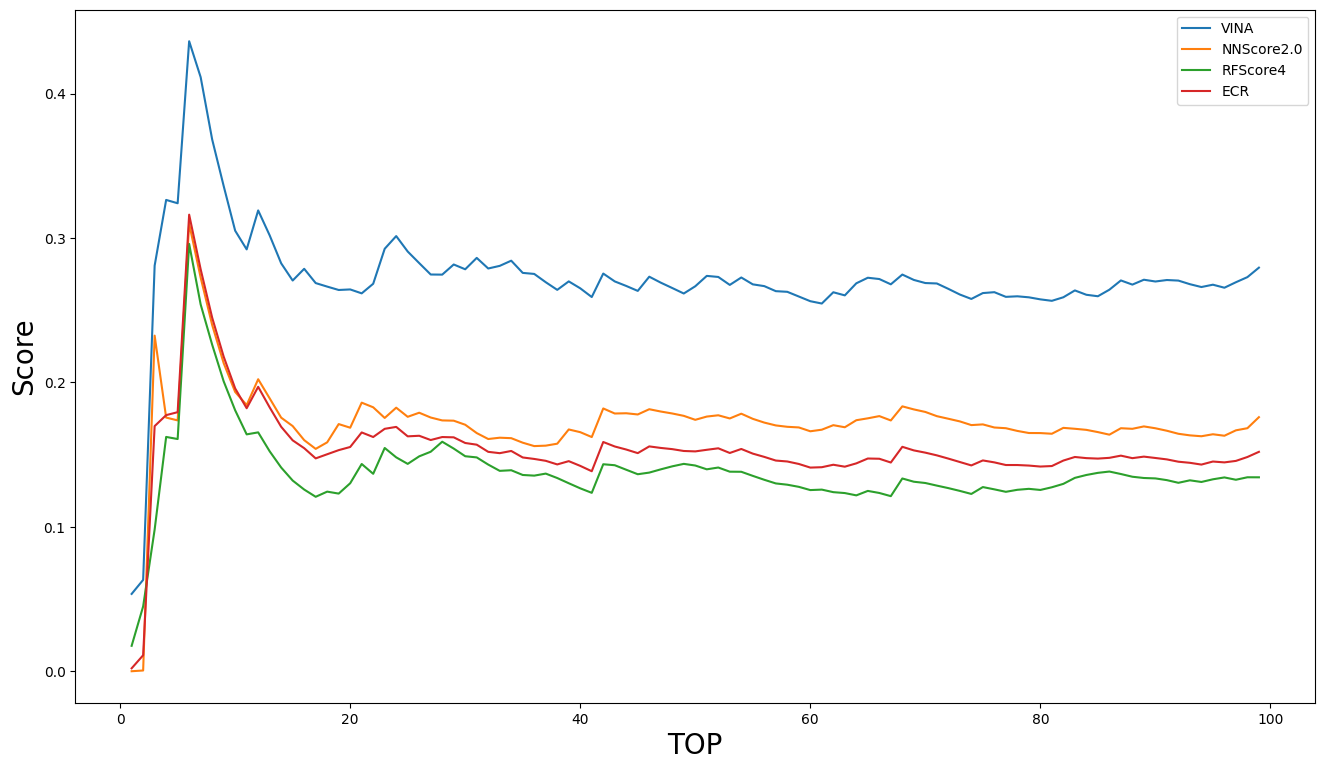

In [15]:
import matplotlib.pyplot as plt

def get_relative_score(column, ref_column):
    worst_prediction = 0
    best_prediction = 0
    vina_prediction = 0
    relative_score = []

    for i in range(0, df_exp.shape[0] - 1):
        best_prediction += df_exp[ref_column][i]
        worst_prediction += df_exp[ref_column][df_exp.shape[0] - i - 1]
        vina_prediction += df_exp[column][i]
        prediction_error = (vina_prediction - best_prediction) / (worst_prediction - best_prediction)
        relative_score.append(prediction_error)
    return relative_score

df_exp = df_exp.sort_values(by="pKd rank").reset_index(drop=True)
vina_score = get_relative_score("Vina rank", "pKd rank")
nn2_score = get_relative_score("NNScore2 rank", "pKd rank")
rf4_score = get_relative_score("RF-Score4 rank", "pKd rank")
ecr_score = get_relative_score("ECR rank", "pKd rank")


max_rank = 100 #df_exp.shape[0]

plt.figure(figsize=(16, 9))
plt.plot(range(1, max_rank), vina_score[:max_rank-1], label="VINA")
plt.plot(range(1, max_rank), nn2_score[:max_rank-1], label="NNScore2.0")
plt.plot(range(1, max_rank), rf4_score[:max_rank-1], label="RFScore4")
plt.plot(range(1, max_rank), ecr_score[:max_rank-1], label="ECR")
plt.legend()
plt.xlabel("TOP", fontsize=20)
plt.ylabel("Score", fontsize=20)
plt.savefig("ecr_validation.png", dpi=300)
plt.show()

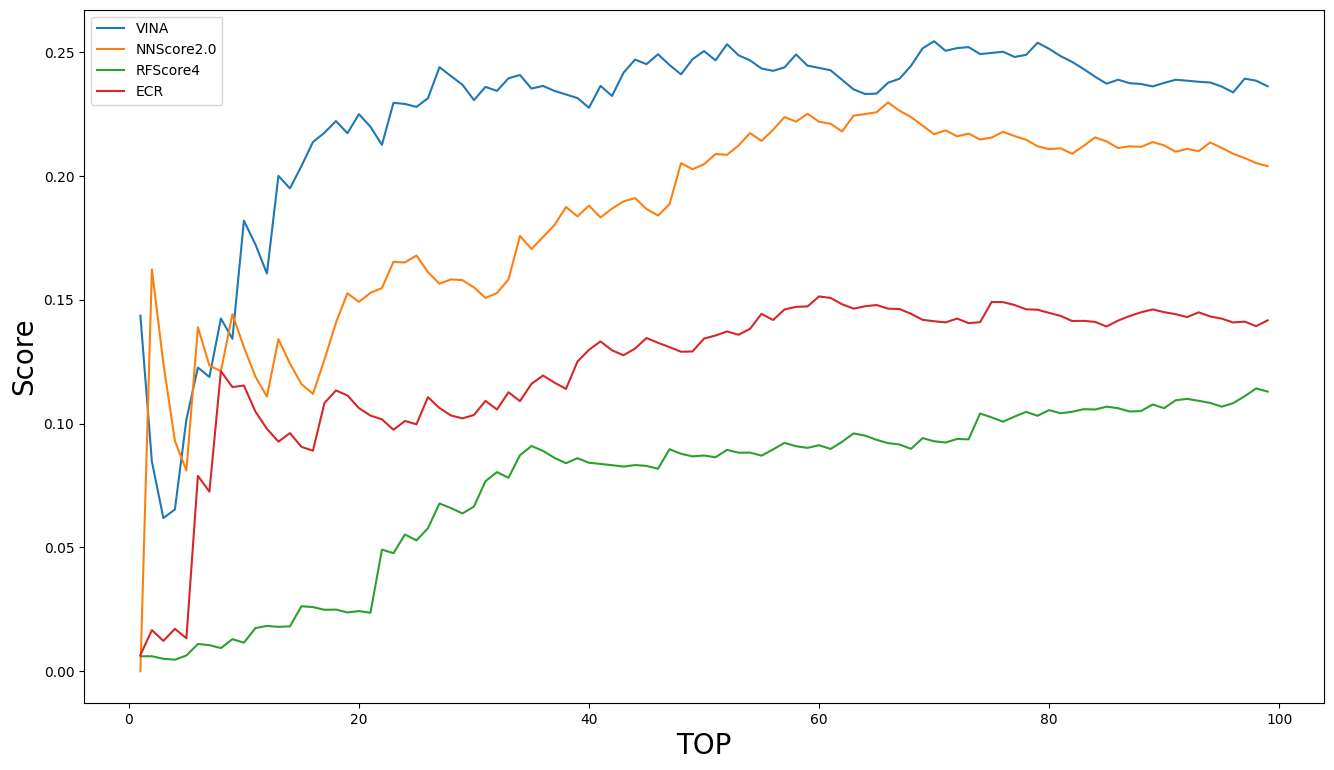

In [16]:
import matplotlib.pyplot as plt

def get_relative_score(column, ref_column):
    worst_prediction = 0
    best_prediction = 0
    vina_prediction = 0
    relative_score = []

    for i in range(0, df_exp.shape[0] - 1):
        best_prediction += df_exp[ref_column][i]
        worst_prediction += df_exp[ref_column][df_exp.shape[0] - i - 1]
        vina_prediction += df_exp[column][i]
        prediction_error = (vina_prediction - best_prediction) / (worst_prediction - best_prediction)
        relative_score.append(prediction_error)
    return relative_score

df_exp = df_exp.sort_values(by="Vina rank").reset_index(drop=True)
vina_score = get_relative_score("pKd rank", "Vina rank")
df_exp = df_exp.sort_values(by="NNScore2 rank").reset_index(drop=True)
nn2_score = get_relative_score("pKd rank", "NNScore2 rank")
df_exp = df_exp.sort_values(by="RF-Score4 rank").reset_index(drop=True)
rf4_score = get_relative_score("pKd rank", "RF-Score4 rank")
df_exp = df_exp.sort_values(by="ECR rank").reset_index(drop=True)
ecr_score = get_relative_score("pKd rank", "ECR rank")


max_rank = 100 #df_exp.shape[0]

plt.figure(figsize=(16, 9))
plt.plot(range(1, max_rank), vina_score[:max_rank-1], label="VINA")
plt.plot(range(1, max_rank), nn2_score[:max_rank-1], label="NNScore2.0")
plt.plot(range(1, max_rank), rf4_score[:max_rank-1], label="RFScore4")
plt.plot(range(1, max_rank), ecr_score[:max_rank-1], label="ECR")
plt.legend()
plt.xlabel("TOP", fontsize=20)
plt.ylabel("Score", fontsize=20)
plt.savefig("ecr_validation_reverse.png", dpi=300)
plt.show()

In [19]:
df_exp.drop(columns=["VINA diff"]).to_csv("exp_pKd_ranks.csv", index=False)

In [10]:
from scipy.stats import pearsonr

print(pearsonr(df_exp["Vina rank"], df_exp["pKd rank"]))
print(pearsonr(df_exp["NNScore2 rank"], df_exp["pKd rank"]))
print(pearsonr(df_exp["RF-Score4 rank"], df_exp["pKd rank"]))
print(pearsonr(df_exp["ECR rank"], df_exp["pKd rank"]))

PearsonRResult(statistic=0.48279874566041836, pvalue=1.0035171912776719e-116)
PearsonRResult(statistic=0.5667571283062438, pvalue=1.7439209800494986e-169)
PearsonRResult(statistic=0.6591238603410357, pvalue=2.477342966920342e-248)
PearsonRResult(statistic=0.6433337377587528, pvalue=6.66511362894029e-233)


In [46]:
df_exp = exprank.get_exprank_df(df_score, "VINA pKd", "NN2 pKd", "RF4 pKd", sigma_vina=5, sigma_nn2=10, sigma_rf4=20, max_rank_regulator=2)
df_exp["pKd percentile"] = df_exp["pKd"].apply( lambda x: percentileofscore(- df_exp["pKd"], - x))
df_exp["ECR percentile"] = df_exp["ECR"].apply( lambda x: percentileofscore(df_exp["ECR"], x))

C:\Users\USER\miniconda3\envs\chem-env\lib\site-packages\scipy\stats\_stats_py.py:112: RuntimeWarning: The input array could not be properly checked for nan values. nan values will be ignored.
  warnings.warn("The input array could not be properly "
C:\Users\USER\miniconda3\envs\chem-env\lib\site-packages\scipy\stats\_stats_py.py:112: RuntimeWarning: The input array could not be properly checked for nan values. nan values will be ignored.
  warnings.warn("The input array could not be properly "
C:\Users\USER\miniconda3\envs\chem-env\lib\site-packages\scipy\stats\_stats_py.py:112: RuntimeWarning: The input array could not be properly checked for nan values. nan values will be ignored.
  warnings.warn("The input array could not be properly "
C:\Users\USER\miniconda3\envs\chem-env\lib\site-packages\scipy\stats\_stats_py.py:112: RuntimeWarning: The input array could not be properly checked for nan values. nan values will be ignored.
  warnings.warn("The input array could not be properly "


In [47]:
print(pearsonr(df_exp["ECR percentile"], df_exp["pKd percentile"]))

PearsonRResult(statistic=-0.6370528301444086, pvalue=1.8907585873153293e-226)


In [26]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
cm = plt.cm.get_cmap('RdYlBu')

In [28]:
df_score["Mol weight"] = df_score["SMILES"].apply(lambda x: Descriptors.ExactMolWt(Chem.MolFromSmiles(x)))

vmin = df_score["Mol weight"].quantile(0.01)
vmax = df_score["Mol weight"].quantile(0.99)
print(vmin, vmax)

94.041864812 828.8395736169604


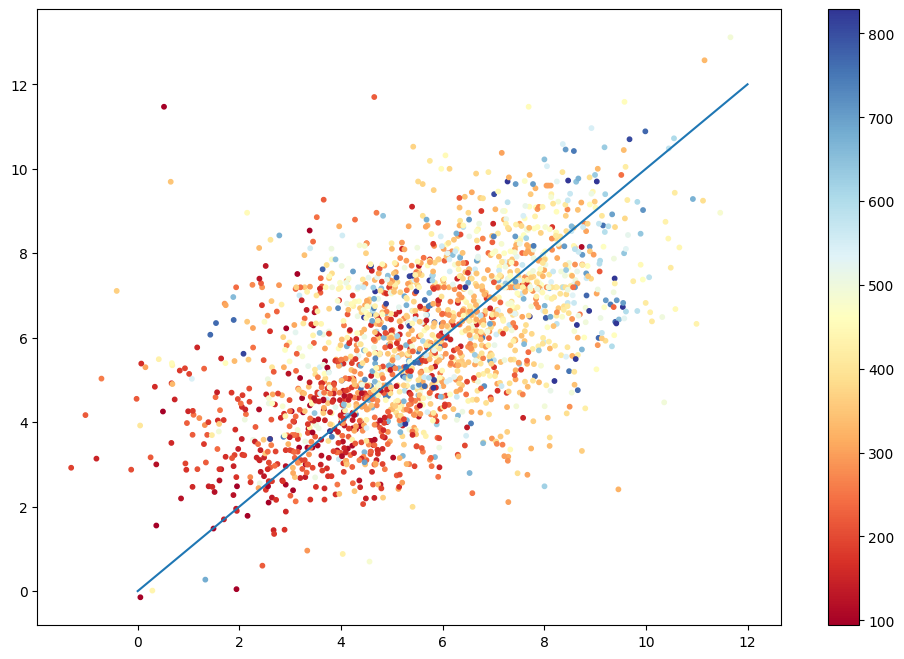

In [29]:
plt.figure(figsize=(12, 8))
plt.plot([0, 12], [0, 12])
sc = plt.scatter(df_score["NN2 pKd"], df_score["pKd"], c=df_score["Mol weight"], vmin=vmin, vmax=vmax, s=10, cmap=cm)
plt.colorbar(sc)
plt.show()

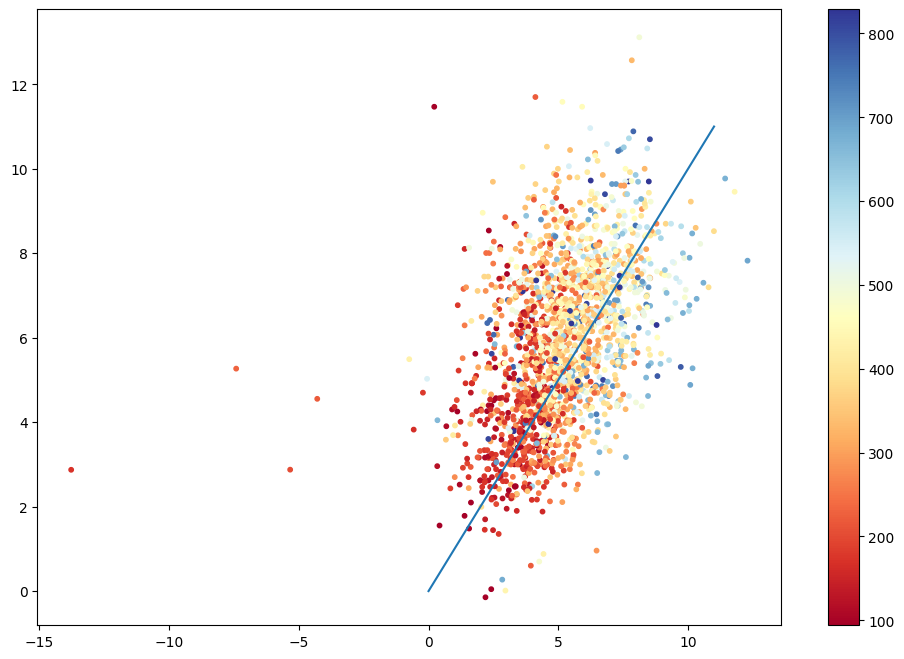

In [30]:
plt.figure(figsize=(12, 8))
plt.plot([0, 11], [0, 11])
sc = plt.scatter(df_score["VINA pKd"], df_score["pKd"], c=df_score["Mol weight"], vmin=vmin, vmax=vmax, s=10, cmap=cm)
plt.colorbar(sc)
plt.show()

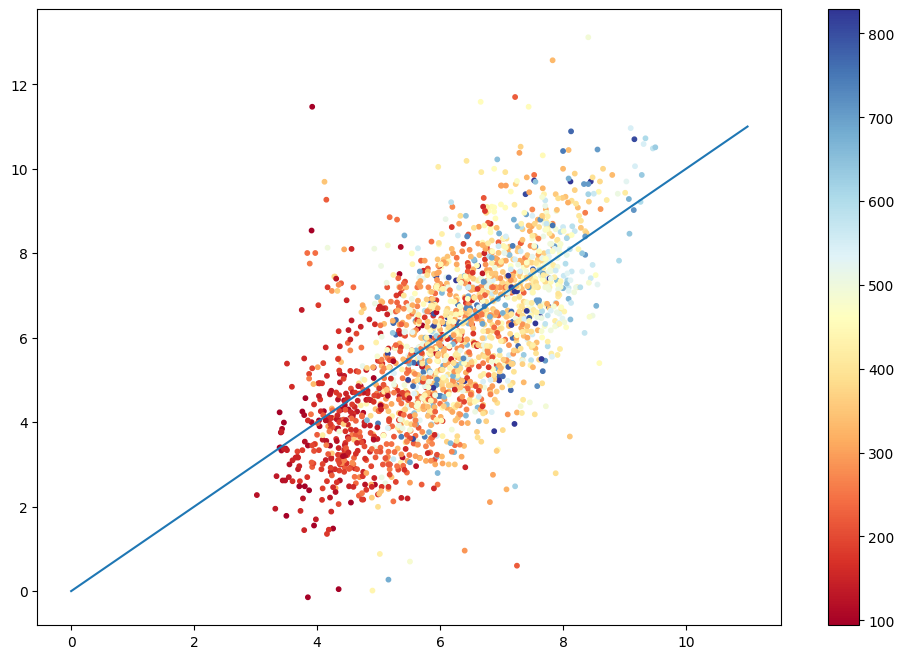

In [31]:
plt.figure(figsize=(12, 8))
plt.plot([0, 11], [0, 11])
sc = plt.scatter(df_score["RF4 pKd"], df_score["pKd"], c=df_score["Mol weight"], vmin=vmin, vmax=vmax, s=10, cmap=cm)
plt.colorbar(sc)
plt.show()